# Employee Satisfaction Analysis
Author: Rohit P.

Goal: Understand what might explain differences in employee satisfaction scores.

**My Notes:**
- Satisfaction scores from 1 (low, very unsatisfied) to 5 (high, very satisfied)
- Employee levels from 1 (junior software engineer) to 4 (principal software engineer)
- Performance rating from 1 (low performing) to 5 (high performing) from most recent annual review.

In [29]:
# import libraries
import numpy as np # numpy is a numerical computing library
import pandas as pd # pansdas is a data manipulation library
import matplotlib.pyplot as plt # matplotlib is a plotting library
import seaborn as sns # seaborn is a statistical plotting library

In [30]:
# import data
df = pd.read_csv('employee_data.csv')

In [31]:
df.head()

,EmployeeID,EmployeeLevel,TenureYears,ProductGroup,Country,WorkLocation,TeamSize,PerformanceRating,SatisfactionScore
0,443683,1,2,GroupA,United States,hybrid,8,5.0,1
1,839543,1,1,GroupC,India,onsite,12,NaN,4
2,426374,1,2,GroupA,India,hybrid,7,2.0,5
3,327187,1,4,GroupB,Canada,hybrid,7,4.0,4
4,298314,1,3,GroupA,Canada,remote,5,5.0,3


In [32]:
# how many rows and columns
df.shape

(4492, 9)

In [33]:
# how many NAs
df.isna().sum()

EmployeeID             0
EmployeeLevel          0
TenureYears            0
ProductGroup           0
Country                0
WorkLocation           0
TeamSize               0
PerformanceRating    995
SatisfactionScore      0
dtype: int64

**My Notes: looks like a handful of employees without performance ratings. I want to keep that variable so I'll drop the records without it.**

In [34]:
# drop NAs
df = df.dropna()
df.shape

(3497, 9)

# Exploratory Data Analysis

### Correlation Coefficients

In [35]:
# get the correlation coefficients and round to 2 decimal places for all columns that are not of type object or category
df[df.select_dtypes(['number']).columns].corr().round(2)


,EmployeeID,EmployeeLevel,TenureYears,TeamSize,PerformanceRating,SatisfactionScore
EmployeeID,1.00,-0.01,0.02,0.01,-0.01,0.00
EmployeeLevel,-0.01,1.00,0.46,-0.01,-0.01,-0.09
TenureYears,0.02,0.46,1.00,0.02,-0.02,-0.21
TeamSize,0.01,-0.01,0.02,1.00,-0.13,-0.20
PerformanceRating,-0.01,-0.01,-0.02,-0.13,1.00,0.12
SatisfactionScore,0.00,-0.09,-0.21,-0.20,0.12,1.00


**My Notes: Looks like there's moderate correlation between EmployeeLevel and TenureYears, that makes sense. Weak negative correlations between SatisfactionScore and TeamSize and TenureYears, which is something to look into.**

### Distributions by Categories

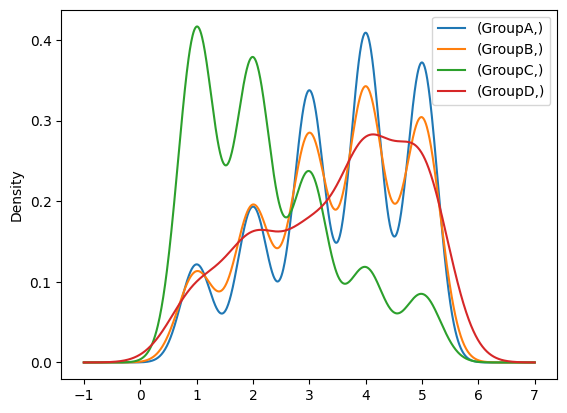

In [36]:
# create a density plot for the SatisfactionScore and facet by ProductGroup using Matplotlib
fig, ax = plt.subplots()
for key, grp in df.groupby(['ProductGroup']):
    ax = grp['SatisfactionScore'].plot.kde(ax=ax, label=key)
ax.legend()
plt.show()



**My Notes: Looks like the distributions for all the product teams look roughly the same, with the exception of GroupC, which looks to have more lower scores than the others. Something to look further into.**

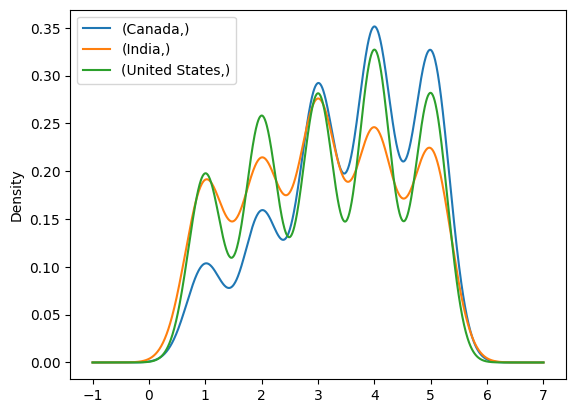

In [37]:
# create a density plot for the SatisfactionScore and facet by ProductGroup using Matplotlib
fig, ax = plt.subplots()
for key, grp in df.groupby(['Country']):
    ax = grp['SatisfactionScore'].plot.kde(ax=ax, label=key)
ax.legend()
plt.show()

**My Notes: looks fairly similar for all with maybe Canadian software engineers having slightly higher satisfaction.** 

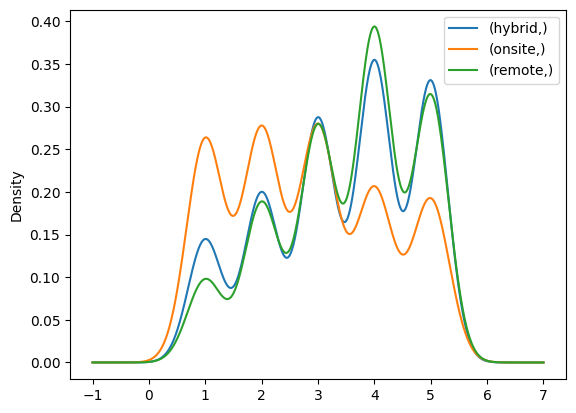

In [38]:
# create a density plot for the SatisfactionScore and facet by ProductGroup using Matplotlib
fig, ax = plt.subplots()
for key, grp in df.groupby(['WorkLocation']):
    ax = grp['SatisfactionScore'].plot.kde(ax=ax, label=key)
ax.legend()
plt.show()

**My Notes: looks fairly similar across work locations, with maybe a slightly higher dissatisfaction with those that work in the office compared to the remote and hybrid work employees.**

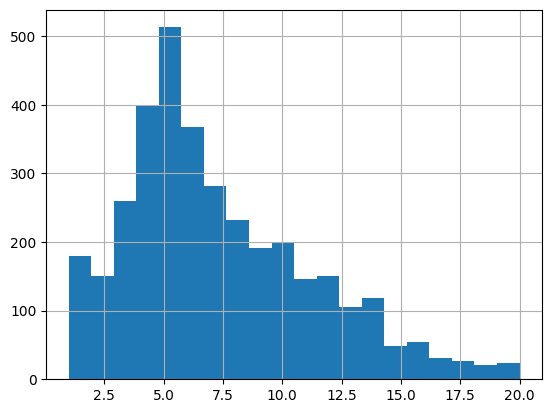

In [39]:
# histogram of TeamSize
df['TeamSize'].hist(bins=20)
plt.show()

**My Notes: most software engineers in teams of 3 to 10 people or so.**

# Ordinary Least Squares Regression

References: 
- https://www.statsmodels.org/stable/examples/notebooks/generated/ols.html

In [40]:
import statsmodels.formula.api as smf # import the statsmodels library

In [41]:
df_ols = df.copy()

# drop EmployeeID column
df_ols = df_ols.drop('EmployeeID', axis=1)

# convert the categorical variables to binary variables
df_ols = pd.get_dummies(df_ols) 

# remove some of the prefix from the column names to make it easier to read
df_ols.columns = df_ols.columns.str.replace('ProductGroup_', '')
df_ols.columns = df_ols.columns.str.replace('Country_', '')
df_ols.columns = df_ols.columns.str.replace('WorkLocation_', '')

In [42]:
df_ols.dtypes

EmployeeLevel          int64
TenureYears            int64
TeamSize               int64
PerformanceRating    float64
SatisfactionScore      int64
GroupA                  bool
GroupB                  bool
GroupC                  bool
GroupD                  bool
Canada                  bool
India                   bool
United States           bool
hybrid                  bool
onsite                  bool
remote                  bool
dtype: object

In [43]:
df_ols.head()

,EmployeeLevel,TenureYears,TeamSize,PerformanceRating,SatisfactionScore,GroupA,GroupB,GroupC,GroupD,Canada,India,United States,hybrid,onsite,remote
0,1,2,8,5.0,1,True,False,False,False,False,False,True,True,False,False
2,1,2,7,2.0,5,True,False,False,False,False,True,False,True,False,False
3,1,4,7,4.0,4,False,True,False,False,True,False,False,True,False,False
4,1,3,5,5.0,3,True,False,False,False,True,False,False,False,False,True
6,3,5,5,5.0,2,True,False,False,False,False,True,False,False,False,True


### OLS Model 1: ProductGroup Splits

In [44]:
model1 = smf.ols(formula = "SatisfactionScore ~ GroupA + GroupB + GroupC + GroupD", data = df_ols) # define model
ols_model1 = model1.fit() # fit model
print(ols_model1.summary()) # print results

                            OLS Regression Results                            
Dep. Variable:      SatisfactionScore   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     135.2
Date:                Sun, 01 Dec 2024   Prob (F-statistic):          1.58e-107
Time:                        22:41:37   Log-Likelihood:                -5733.8
No. Observations:                3497   AIC:                         1.148e+04
Df Residuals:                    3492   BIC:                         1.151e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -4.216e+12   2.48e+12     -1.

**My Notes: I'm not really sure why all the coefficients, t-statistics, and other values are the same. But the p-values are all greater than 0.05 so I think they're just not signficant.**

### OLS Model 2: EmployeeLevel, TeamSize, PerformanceRating

In [45]:
model2 = smf.ols(formula = "SatisfactionScore ~ EmployeeLevel + TeamSize + PerformanceRating", data = df_ols) # define model
ols_model2 = model2.fit() # fit model
print(ols_model2.summary()) # print results

                            OLS Regression Results                            
Dep. Variable:      SatisfactionScore   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     73.31
Date:                Sun, 01 Dec 2024   Prob (F-statistic):           5.56e-46
Time:                        22:41:38   Log-Likelihood:                -5878.8
No. Observations:                3497   AIC:                         1.177e+04
Df Residuals:                    3493   BIC:                         1.179e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.6300      0.08

**My Notes: these values all have a low p-value, so worth calling out. The higher the employee level, the more negative impacts on the satisfaction score. The larger the team size, the more negative impacts on the satisfaction score, and the better the performance rating, the better the satisfaction score.**

# Random Forest
The team is really interested to figure out what might be leading people to respond with very low satisfaction on the employee survey. So we're going to turn that into a specific binary category to call out and see if we can use a random forest model to see what is causing that. 

Resources: 
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn.model_selection.train_test_split
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html


In [46]:
from sklearn.model_selection import train_test_split
from sklearn import ensemble
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [47]:
df_rf = df.copy()

# drop EmployeeID column
df_rf = df_rf.drop('EmployeeID', axis=1)

# convert SatisfactionScore to categorical
df_rf['SatisfactionScore'] = df_rf['SatisfactionScore'].astype('category')

# convert the categorical variables to dummy binary variables
df_rf = pd.get_dummies(df_rf) 

# remove some of the prefix from the column names to make it easier to read
df_rf.columns = df_rf.columns.str.replace('ProductGroup_', '')
df_rf.columns = df_rf.columns.str.replace('Country_', '')
df_rf.columns = df_rf.columns.str.replace('WorkLocation_', '')

In [48]:
# print column names
df_rf.dtypes

EmployeeLevel            int64
TenureYears              int64
TeamSize                 int64
PerformanceRating      float64
GroupA                    bool
GroupB                    bool
GroupC                    bool
GroupD                    bool
Canada                    bool
India                     bool
United States             bool
hybrid                    bool
onsite                    bool
remote                    bool
SatisfactionScore_1       bool
SatisfactionScore_2       bool
SatisfactionScore_3       bool
SatisfactionScore_4       bool
SatisfactionScore_5       bool
dtype: object

In [49]:
df_rf.head()

,EmployeeLevel,TenureYears,TeamSize,PerformanceRating,GroupA,GroupB,GroupC,GroupD,Canada,India,United States,hybrid,onsite,remote,SatisfactionScore_1,SatisfactionScore_2,SatisfactionScore_3,SatisfactionScore_4,SatisfactionScore_5
0,1,2,8,5.0,True,False,False,False,False,False,True,True,False,False,True,False,False,False,False
2,1,2,7,2.0,True,False,False,False,False,True,False,True,False,False,False,False,False,False,True
3,1,4,7,4.0,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False
4,1,3,5,5.0,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False
6,3,5,5,5.0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False


In [50]:
# get the value counts for the column SatisfactionScore_1
df_rf['SatisfactionScore_1'].value_counts()

SatisfactionScore_1
False    3015
True      482
Name: count, dtype: int64

In [51]:
482 / (482 + 3015)

0.13783242779525307

**My Notes: so roughly 14% are very low satisfaction, and 86% are in the other response groups.**

In [52]:
X = df_rf.iloc[:,:-5] # get all the columns other than the satisfaction score columns and put in the independent variable dataset
y = df_rf.iloc[:,-5] # have the SatisfactionScore_1 column as the dependent variable

In [53]:
X.columns

Index(['EmployeeLevel', 'TenureYears', 'TeamSize', 'PerformanceRating',
       'GroupA', 'GroupB', 'GroupC', 'GroupD', 'Canada', 'India',
       'United States', 'hybrid', 'onsite', 'remote'],
      dtype='object')

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0) # default is 75% / 25% train-test split

rf = ensemble.RandomForestClassifier(random_state=0)

rf.fit(X_train, y_train)

print(rf.score(X_test, y_test))

0.8182857142857143


**My Notes: model accuracy on test set is ~82%.**

              precision    recall  f1-score   support

       False       0.85      0.96      0.90       736
        True       0.27      0.09      0.13       139

    accuracy                           0.82       875
   macro avg       0.56      0.52      0.51       875
weighted avg       0.76      0.82      0.78       875

 1) TeamSize                       0.322848
 2) TenureYears                    0.241398
 3) PerformanceRating              0.149003
 4) EmployeeLevel                  0.110801
 5) GroupC                         0.047723
 6) onsite                         0.020618
 7) GroupA                         0.019612
 8) United States                  0.017179
 9) hybrid                         0.014717
10) India                          0.014704
11) GroupB                         0.014000
12) Canada                         0.012454
13) remote                         0.010909
14) GroupD                         0.004034


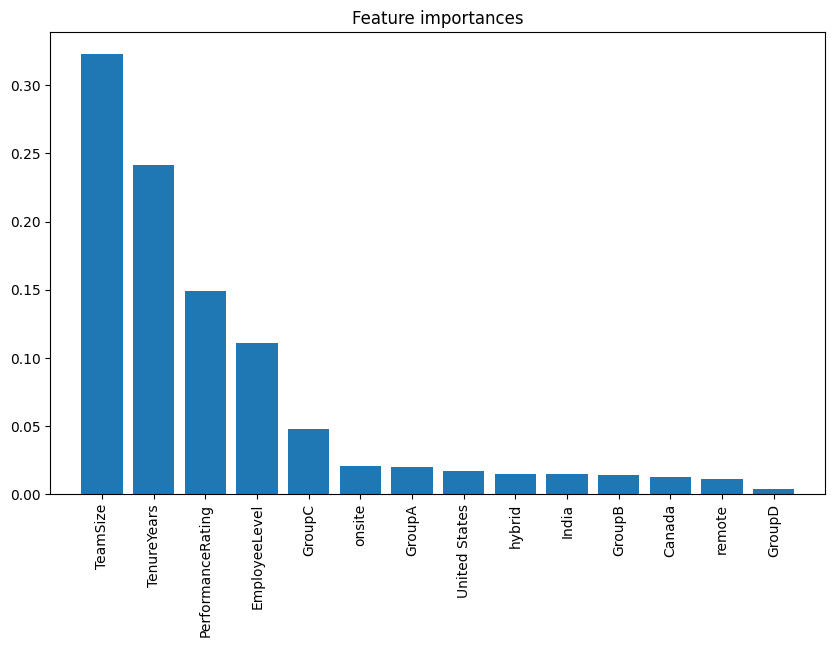

In [82]:
# create confusion matrix and classification report
y_pred = rf.predict(X_test)
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

# print feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

for f in range(X.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30, X.columns.values[indices[f]], importances[indices[f]]))

# plot feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns.values[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

**My Notes: Team size seems to be the feature with the most importance, so we should call that out too.** 

In [83]:
print("Done!")

Done!
